In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
import os
print(os.path.getsize("car.csv"))

17209


In [7]:
import pandas as pd

df = pd.read_csv("car.csv")
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    str    
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    str    
 6   Seller_Type    301 non-null    str    
 7   Transmission   301 non-null    str    
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), str(4)
memory usage: 21.3 KB


In [9]:
df['Car_Age'] = 2026 - df['Year']
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Car_Age
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0,12
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0,13
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0,9
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0,15
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0,12


In [10]:
df.drop(['Car_Name','Year'], axis=1, inplace=True)
df.head()

,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Car_Age
0,3.35,5.59,27000,Petrol,Dealer,Manual,0,12
1,4.75,9.54,43000,Diesel,Dealer,Manual,0,13
2,7.25,9.85,6900,Petrol,Dealer,Manual,0,9
3,2.85,4.15,5200,Petrol,Dealer,Manual,0,15
4,4.60,6.87,42450,Diesel,Dealer,Manual,0,12


In [11]:
df = pd.get_dummies(df, drop_first=True)
df.head()

,Selling_Price,Present_Price,Kms_Driven,Owner,Car_Age,Fuel_Type_Diesel,Fuel_Type_Petrol,Seller_Type_Individual,Transmission_Manual
0,3.35,5.59,27000,0,12,False,True,False,True
1,4.75,9.54,43000,0,13,True,False,False,True
2,7.25,9.85,6900,0,9,False,True,False,True
3,2.85,4.15,5200,0,15,False,True,False,True
4,4.60,6.87,42450,0,12,True,False,False,True


In [13]:
X = df.drop('Selling_Price', axis=1)
y = df['Selling_Price']

In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [15]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor()
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [16]:
y_pred = model.predict(X_test)
y_pred[:5]

array([ 0.4535, 11.0049,  4.978 ,  0.2121,  7.6695])

In [17]:
from sklearn.metrics import r2_score

print("Accuracy:", r2_score(y_test, y_pred))

Accuracy: 0.9602827548226159


In [19]:
import pandas as pd

new_car = pd.DataFrame([[
    9.54, 43000, 0, 13, 1, 0, 0, 1
]], columns=X.columns)

model.predict(new_car)

array([5.032])

In [20]:
df.describe()

,Selling_Price,Present_Price,Kms_Driven,Owner,Car_Age
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,4.661296,7.628472,36947.205980,0.043189,12.372093
std,5.082812,8.644115,38886.883882,0.247915,2.891554
min,0.100000,0.320000,500.000000,0.000000,8.000000
25%,0.900000,1.200000,15000.000000,0.000000,10.000000
50%,3.600000,6.400000,32000.000000,0.000000,12.000000
75%,6.000000,9.900000,48767.000000,0.000000,14.000000
max,35.000000,92.600000,500000.000000,3.000000,23.000000


Task was destroyed but it is pending!
task: <Task pending name='Task-202' coro=<_async_in_context.<locals>.run_in_context() done, defined at C:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\ipykernel\utils.py:57> wait_for=<Task pending name='Task-203' coro=<Kernel.shell_main() running at C:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\ipykernel\kernelbase.py:597> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at C:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\zmq\eventloop\zmqstream.py:563]>
C:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\matplotlib_inline\backend_inline.py:13: RuntimeWarning: coroutine 'Kernel.shell_main' was never awaited
  from matplotlib.backends import backend_agg
Task was destroyed but it is pending!
task: <Task pending name='Task-203' coro=<Kernel.shell_main() running at C:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\site-pac

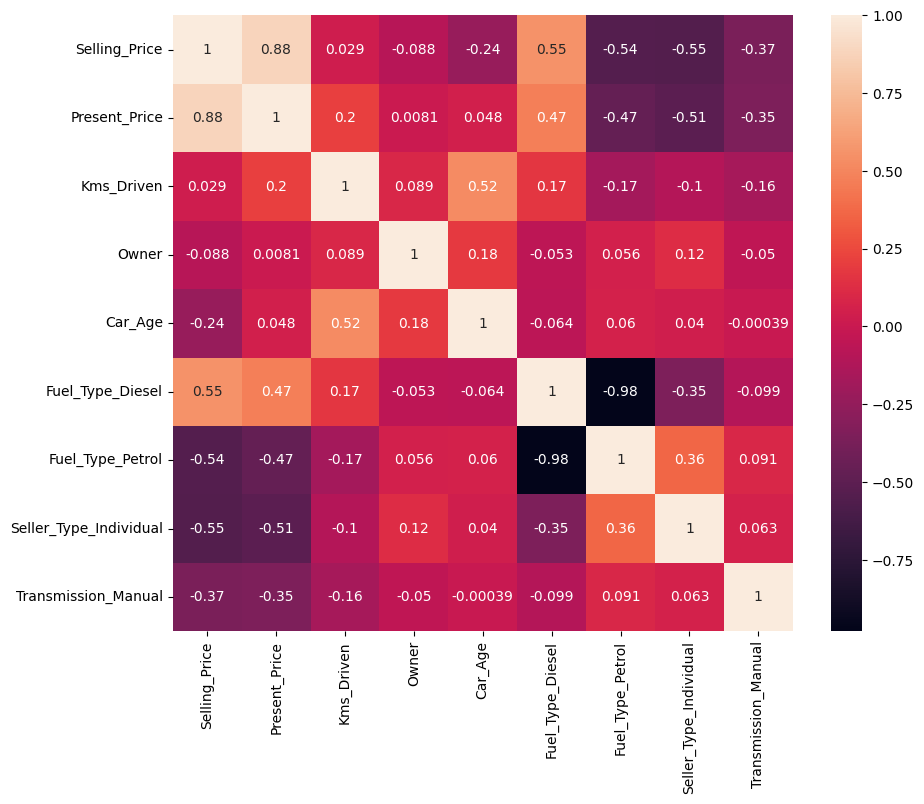

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True)
plt.show()

In [22]:
print("Notebook Working")

Notebook Working


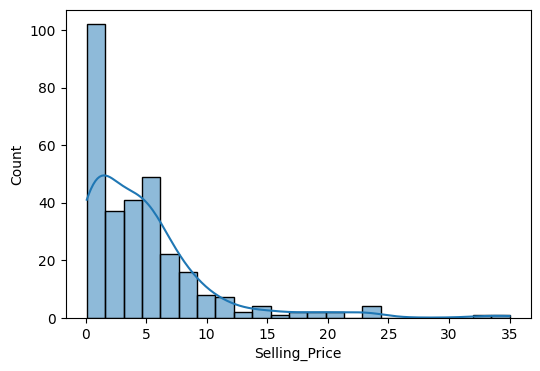

In [23]:
plt.figure(figsize=(6,4))
sns.histplot(df['Selling_Price'], kde=True)
plt.show()

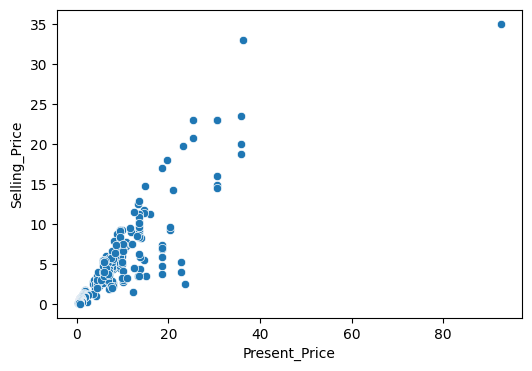

In [24]:
plt.figure(figsize=(6,4))
sns.scatterplot(x=df['Present_Price'], y=df['Selling_Price'])
plt.show()

In [25]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor

params = {
    'n_estimators': [100,200,300,500],
    'max_depth': [5,10,15,20,None],
    'min_samples_split': [2,5,10],
    'min_samples_leaf': [1,2,4]
}

rf = RandomForestRegressor(random_state=42)

search = RandomizedSearchCV(
    rf,
    params,
    n_iter=20,
    cv=5,
    scoring='r2',
    random_state=42
)

search.fit(X_train, y_train)

best_model = search.best_estimator_

print(search.best_params_)

{'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': None}


In [26]:
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

pred = best_model.predict(X_test)

print("R2 Score:", r2_score(y_test, pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, pred)))

R2 Score: 0.9598980320504796
RMSE: 0.9611307258282548


In [27]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance)

                  Feature  Importance
0           Present_Price    0.886949
3                 Car_Age    0.059042
1              Kms_Driven    0.035633
7     Transmission_Manual    0.008548
4        Fuel_Type_Diesel    0.003463
5        Fuel_Type_Petrol    0.003144
6  Seller_Type_Individual    0.002085
2                   Owner    0.001137


In [28]:
import pickle

pickle.dump(
    best_model,
    open('car_price_model.pkl', 'wb')
)

In [29]:
import pickle

pickle.dump(model, open('car_price_model.pkl', 'wb'))

print("Model Saved Successfully")

Model Saved Successfully


In [30]:
loaded_model = pickle.load(open('car_price_model.pkl', 'rb'))

prediction = loaded_model.predict(new_car)

print(prediction)

[5.032]
